In [1]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ERA5_to_latent.zarr")
ds

<xarray.Dataset> Size: 19GB
Dimensions:  (time: 7670, lat: 180, lon: 270)
Coordinates:
  * lat      (lat) float64 1kB 40.01 40.08 40.14 40.21 ... 51.86 51.92 51.99
  * lon      (lon) float64 2kB 2.008 2.075 2.142 2.209 ... 19.86 19.92 19.99
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-30
Data variables:
    cos_doy  (time, lat, lon) float64 3GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    dem      (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    q_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    sin_doy  (time, lat, lon) float64 3GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    ssrd     (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    t2m      (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    t_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    tp       (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    u_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    v_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    z_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ERA5_to_latent.zarr")

# Loop through each variable and plot its histogram
for var in ds.data_vars:
    data = ds[var].values.flatten()
    
    # Remove NaNs and Infs
    data = data[~xr.ufuncs.isnan(data)]
    data = data[~xr.ufuncs.isinf(data)]

    # Skip if variable is empty
    if data.size == 0:
        continue

    # Plot
    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=100, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


AttributeError: module 'xarray' has no attribute 'ufuncs'

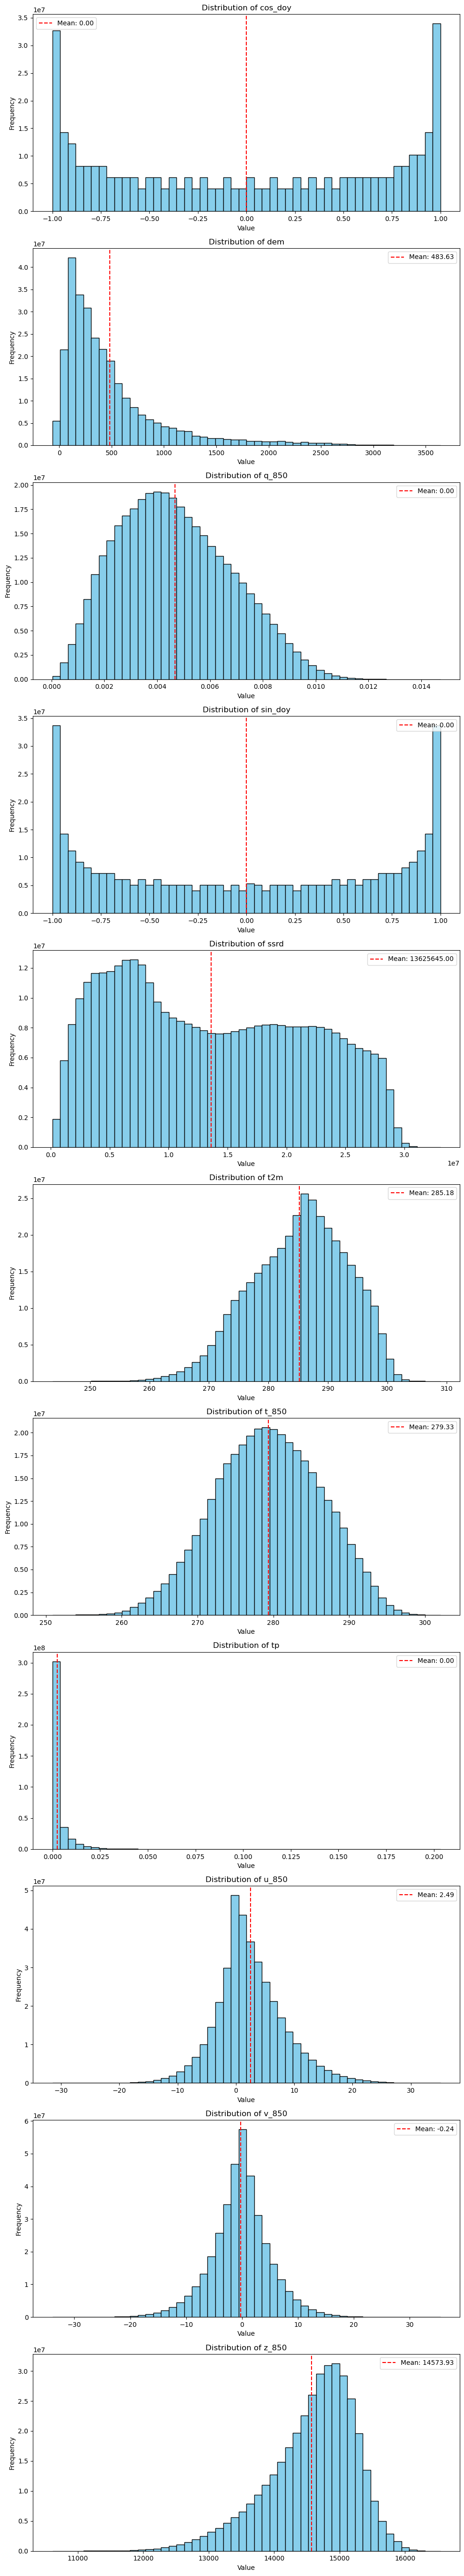

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the dataset
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ERA5_to_latent.zarr")

# Create a figure with subplots for each variable
num_vars = len(ds.data_vars)
fig, axes = plt.subplots(nrows=num_vars, figsize=(10, 5*num_vars), squeeze=False)
axes = axes.flatten()

# Plot histograms for each variable
for i, (var_name, da) in enumerate(ds.data_vars.items()):
    # Compute histogram (using dask if needed)
    hist = da.plot.hist(ax=axes[i], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {var_name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add vertical line at mean
    mean_val = da.mean().compute().item()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [13]:
from openeo.local import LocalConnection

stac_item = "https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_AUGUST_2021"

local_conn = LocalConnection("./")

single = local_conn.load_stac(
    url=stac_item,
    bands=['tp', 'pet', 't2m', 'ssrd']
).execute().to_dataset(dim='bands')
single

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 216, number: 51, y: 49, x: 73)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * x        (x) float32 292B 2.0 2.25 2.5 2.75 3.0 ... 19.25 19.5 19.75 20.0
  * y        (y) float32 196B 52.0 51.75 51.5 51.25 ... 40.75 40.5 40.25 40.0
Data variables:
    tp       (time, number, y, x) float64 315MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    pet      (time, number, y, x) float64 315MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    t2m      (time, number, y, x) float64 315MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 315MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [14]:
from openeo.local import LocalConnection

stac_item = "https://stac.intertwin.fedcloud.eu/collections/PRESSURE_LEVELS_DAILY_SEAS5_AUGUST_2021"

local_conn = LocalConnection("./")

pressure = local_conn.load_stac(
    url=stac_item,
    bands=['q_850', 't_850', 'u_850', 'v_850', 'z_850']
).execute().to_dataset(dim='bands')
pressure

<xarray.Dataset> Size: 788MB
Dimensions:  (time: 216, number: 51, y: 49, x: 73)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * x        (x) float32 292B 2.0 2.25 2.5 2.75 3.0 ... 19.25 19.5 19.75 20.0
  * y        (y) float32 196B 52.0 51.75 51.5 51.25 ... 40.75 40.5 40.25 40.0
Data variables:
    q_850    (time, number, y, x) float32 158MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    t_850    (time, number, y, x) float32 158MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    u_850    (time, number, y, x) float32 158MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    v_850    (time, number, y, x) float32 158MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
    z_850    (time, number, y, x) float32 158MB dask.array<chunksize=(216, 1, 49, 73), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [19]:
merged_ds = xr.merge([single, pressure])
merged_ds_1 = merged_ds.isel(number=0)

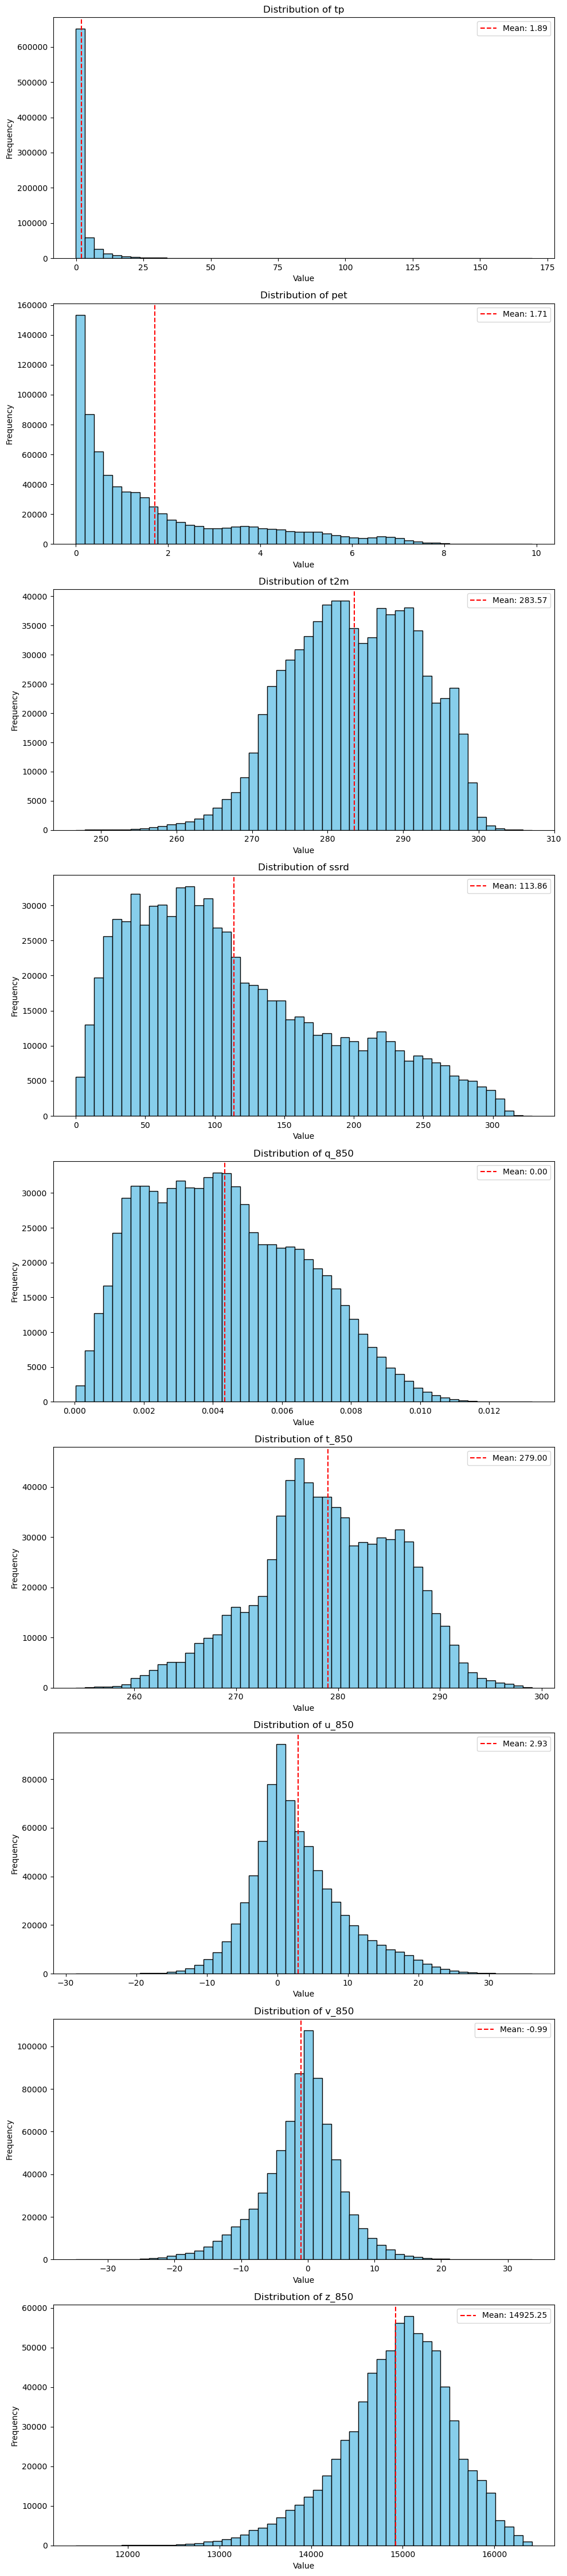

In [20]:
# Create a figure with subplots for each variable
num_vars = len(merged_ds_1.data_vars)
fig, axes = plt.subplots(nrows=num_vars, figsize=(10, 5*num_vars), squeeze=False)
axes = axes.flatten()

# Plot histograms for each variable
for i, (var_name, da) in enumerate(merged_ds_1.data_vars.items()):
    # Compute histogram (using dask if needed)
    hist = da.plot.hist(ax=axes[i], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {var_name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add vertical line at mean
    mean_val = da.mean().compute().item()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [7]:
import xarray as xr

ds_original = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ERA5_to_latent.zarr/")
ds_original = ds_original.sel(lat=slice(42, 51), lon=slice(4, 16))
ds_original

<xarray.Dataset> Size: 10GB
Dimensions:  (time: 7670, lat: 135, lon: 180)
Coordinates:
  * lat      (lat) float64 1kB 42.02 42.08 42.15 42.22 ... 50.85 50.92 50.99
  * lon      (lon) float64 1kB 4.014 4.081 4.148 4.214 ... 15.85 15.91 15.98
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-30
Data variables:
    cos_doy  (time, lat, lon) float64 1GB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    dem      (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    q_850    (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    sin_doy  (time, lat, lon) float64 1GB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    ssrd     (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    t2m      (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    t_850    (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    tp       (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    u_850    (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    v_850    (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
    z_850    (time, lat, lon) float32 746MB dask.array<chunksize=(1000, 20, 20), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [8]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/t2m_latents_v1.zarr/")
ds_updated = ds.assign_coords(
    lat=ds_original.lat,
    lon=ds_original.lon,
    time=ds_original.time
)



<xarray.Dataset> Size: 7GB
Dimensions:   (time: 7670, lat: 135, lon: 180)
Coordinates:
  * lat       (lat) float64 1kB 42.02 42.08 42.15 42.22 ... 50.85 50.92 50.99
  * lon       (lon) float64 1kB 4.014 4.081 4.148 4.214 ... 15.85 15.91 15.98
  * time      (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-30
Data variables:
    latent_A  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_B  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_C  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_D  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_E  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_F  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_G  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_H  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>
    latent_I  (time, lat, lon) float32 746MB dask.array<chunksize=(959, 17, 23), meta=np.ndarray>

In [9]:
ds_updated.to_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/t2m_latents_v1_1.zarr/")

In [10]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/t2m_test_predictions_v1_1.zarr/")
ds


<xarray.Dataset> Size: 4MB
Dimensions:  (time: 1095, y: 15, x: 30)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2018-01-01 2018-01-02 ... 2020-12-30
  * x        (x) float64 240B 10.03 10.1 10.16 10.23 ... 11.77 11.84 11.9 11.97
  * y        (y) float64 120B 46.03 46.1 46.17 46.23 ... 46.77 46.84 46.9 46.97
Data variables:
    t2m      (time, y, x) float64 4MB dask.array<chunksize=(548, 8, 15), meta=np.ndarray>

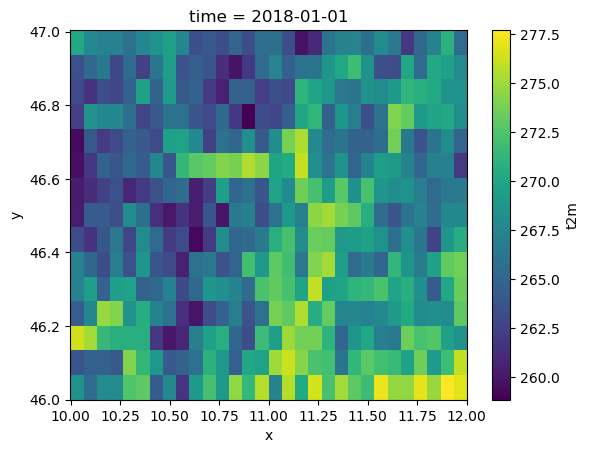

In [11]:
ds.t2m.isel(time=0).plot()

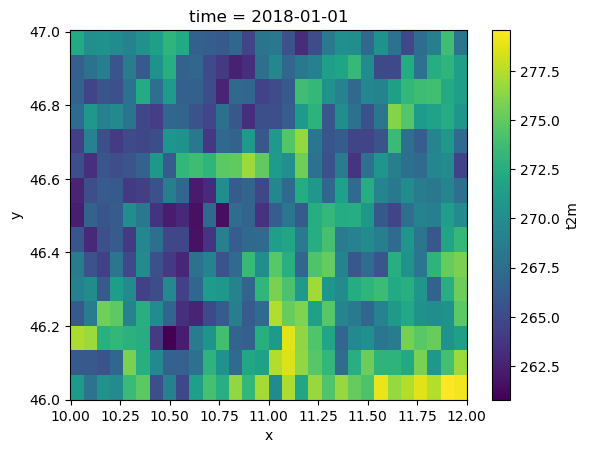

In [12]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/t2m_test_predictions.zarr/")
ds.t2m.isel(time=0).plot()


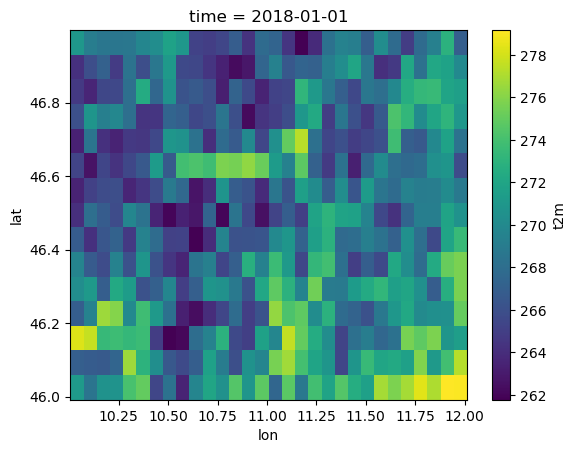

In [15]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/EMO1_STAGE1_2000_2022_t2m_tp_ssrd_pet.zarr/")
ds = ds.sel(lat=slice(46, 47), lon=slice(10, 12))
ds.t2m.sel(time="2018-01-01").plot()

In [4]:
import xarray as xr
l = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/latents_v2.1.zarr")
l = l.assign_coords(
    lat=ds.lat,
    lon=ds.lon,
    time=ds.time
)
l.to_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/latents_v2.2.zarr")

<xarray.Dataset> Size: 299MB
Dimensions:    (time: 5843, lat: 20, lon: 40)
Coordinates:
  * lat        (lat) float64 160B 46.02 46.07 46.12 46.17 ... 46.88 46.93 46.98
  * lon        (lon) float64 320B 10.03 10.08 10.13 10.18 ... 11.88 11.93 11.98
  * time       (time) datetime64[ns] 47kB 2005-01-01 2005-01-02 ... 2020-12-30
Data variables: (12/16)
    latent_0   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_1   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_10  (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_11  (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_12  (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_13  (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    ...         ...
    latent_4   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_5   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_6   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_7   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_8   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>
    latent_9   (time, lat, lon) float32 19MB dask.array<chunksize=(1461, 5, 20), meta=np.ndarray>

In [3]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ERA5_to_latent_by_3.zarr/")
ds = ds.sel(time=slice("2005-01-01", "2020-12-31"))
ds = ds.sel(lat=slice(46, 47), lon=slice(10, 12))
ds

<xarray.Dataset> Size: 243MB
Dimensions:  (time: 5843, lat: 20, lon: 40)
Coordinates:
  * lat      (lat) float64 160B 46.02 46.07 46.12 46.17 ... 46.88 46.93 46.98
  * lon      (lon) float64 320B 10.03 10.08 10.13 10.18 ... 11.88 11.93 11.98
  * time     (time) datetime64[ns] 47kB 2005-01-01 2005-01-02 ... 2020-12-30
Data variables:
    cos_doy  (time, lat, lon) float64 37MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    dem      (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    q_850    (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    sin_doy  (time, lat, lon) float64 37MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    ssrd     (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    t2m      (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    t_850    (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    tp       (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    u_850    (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    v_850    (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
    z_850    (time, lat, lon) float32 19MB dask.array<chunksize=(173, 20, 30), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [5]:
l.to_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/latents_v2.2.zarr")

/home/sdhinakaran/micromamba/envs/zarr_downScaleML/lib/python3.11/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home/sdhinakaran/micromamba/envs/zarr_downScaleML/lib/python3.11/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'h5netcdf' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home/sdhinakaran/micromamba/envs/zarr_downScaleML/lib/python3.11/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


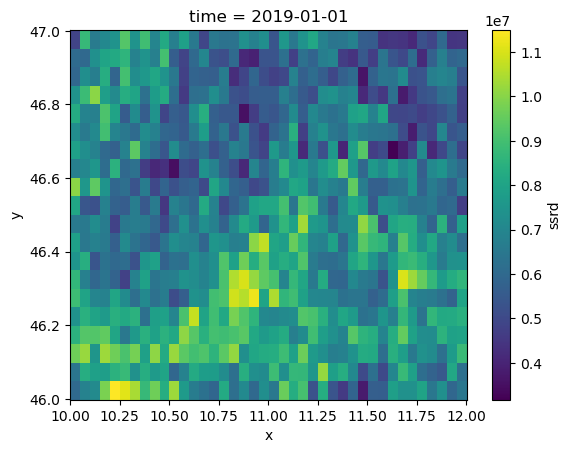

In [18]:
import xarray as xr

ds = xr.open_dataset("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/ssrd_test_predictions_v1_2.zarr")
ds.ssrd.sel(time="2019-01-01").plot()

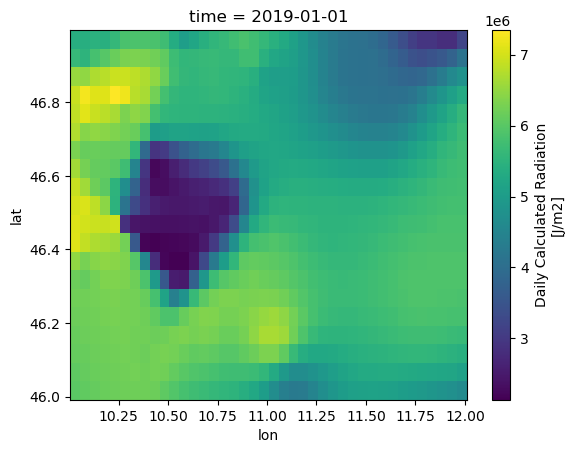

In [19]:
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/EMO1_STAGE1_2000_2022_t2m_tp_ssrd_pet_by_3.zarr/")
ds = ds.sel(lat=slice(46, 47), lon=slice(10, 12))
ds.ssrd.sel(time="2019-01-01").plot()